# Index Exclusion Prediction Analysis
### A Complete 12-Phase Machine Learning Study (2020–2024)
---

In [3]:
# ─── Install dependencies ───────────────────────────────────────────
# !pip install imbalanced-learn statsmodels scikit-learn openpyxl matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 🔹 PHASE 1: Data Understanding

### Step 1.1 – Load & Inspect Data

In [7]:
FILE_PATH = '/Users/mac/Desktop/INDex/IE Dataset.xlsx'

df_raw = pd.read_excel(FILE_PATH, sheet_name='IE Data')

print(f'Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'\nColumns:\n{df_raw.columns.tolist()}')
df_raw.head()

Shape: 337 rows × 16 columns

Columns:
['Year', 'Firm ID', 'Sector', 'Company Name', 'Index Exclusion Status', 'Debt Equity Ratio', 'Current Ratio', 'ROA (%)', 'Interest Coverage Ratio', 'EBIT Margin (%)', 'Operating Cash Flow (Rs.000)', 'Stock Return', 'Stock Volatility', 'Trading Volume', 'GDP (constant LCU)', 'Inflation, consumer prices (annual %)']


,Year,Firm ID,Sector,Company Name,Index Exclusion Status,Debt Equity Ratio,Current Ratio,ROA (%),Interest Coverage Ratio,EBIT Margin (%),Operating Cash Flow (Rs.000),Stock Return,Stock Volatility,Trading Volume,GDP (constant LCU),"Inflation, consumer prices (annual %)"
0,2020,NaN,Textile,Indus Dyeing & Manufacturing Ltd,1,1.054398,1.875315,3.946436,4.069189,6.199390,4058438.0,-0.045591,0.711592,162150,36710346000000,9.740116
1,2020,NaN,Textile,Shahtaj Textile Ltd,1,1.359242,1.634516,2.569785,2.594476,4.428017,562752.0,-0.254492,0.662171,203400,36710346000000,9.740116
2,2020,NaN,Textile,Azgard Nine Ltd,0,19.519571,0.442344,-1.694632,1.048607,6.264121,1342921.0,1.254755,0.544011,854731707,36710346000000,9.740116
3,2020,NaN,Textile,Feroze 1888 Mills Ltd,0,1.037950,1.537181,6.815427,13.358786,11.634370,3675597.0,0.106382,0.388991,10332055,36710346000000,9.740116
4,2020,NaN,Textile,Gul Ahmed Textile Mills Ltd,0,3.398956,1.014311,-0.871246,1.088827,3.274178,110320.0,-0.180602,0.437737,362014560,36710346000000,9.740116


In [8]:
print('Dataset Info:')
df_raw.info()

print('\nTime Period:')
print(f"Years covered: {sorted(df_raw['Year'].unique())}")
print(f"Number of unique firms: {df_raw['Company Name'].nunique()}")
print(f"Sectors: {df_raw['Sector'].unique()}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Year                                   337 non-null    int64  
 1   Firm ID                                0 non-null      float64
 2   Sector                                 337 non-null    object 
 3   Company Name                           337 non-null    object 
 4   Index Exclusion Status                 337 non-null    int64  
 5   Debt Equity Ratio                      335 non-null    float64
 6   Current Ratio                          335 non-null    float64
 7   ROA (%)                                335 non-null    float64
 8   Interest Coverage Ratio                312 non-null    float64
 9   EBIT Margin (%)                        328 non-null    float64
 10  Operating Cash Flow (Rs.000)           335 non-null    float

In [9]:
# Variable summary table
var_table = pd.DataFrame({
    'Variable': df_raw.columns,
    'Type': df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count': df_raw.isnull().sum().values,
    'Role': [
        'Identifier', 'Identifier', 'Identifier', 'Identifier',
        'Dependent Variable (DV)',
        'IV – Financial', 'IV – Financial', 'IV – Financial',
        'IV – Financial', 'IV – Financial',
        'IV – Financial', 'IV – Market', 'IV – Market', 'IV – Market',
        'IV – Macro', 'IV – Macro'
    ]
})
var_table

,Variable,Type,Non-Null Count,Null Count,Role
0,Year,int64,337,0,Identifier
1,Firm ID,float64,0,337,Identifier
2,Sector,object,337,0,Identifier
3,Company Name,object,337,0,Identifier
4,Index Exclusion Status,int64,337,0,Dependent Variable (DV)
5,Debt Equity Ratio,float64,335,2,IV – Financial
6,Current Ratio,float64,335,2,IV – Financial
7,ROA (%),float64,335,2,IV – Financial
8,Interest Coverage Ratio,float64,312,25,IV – Financial
9,EBIT Margin (%),float64,328,9,IV – Financial


### Step 1.2 – Define Variables

In [11]:
# ─── DV ────────────────────────────────────────────────────────────────────────
DV = 'Index Exclusion Status'      # 0 = Not Excluded  |  1 = Excluded

# ─── Independent Variables (ALL retained) ──────────────────────────────────────
FINANCIAL_IVs = [
    'Debt Equity Ratio',
    'Current Ratio',
    'ROA (%)',
    'Interest Coverage Ratio',
    'EBIT Margin (%)',
    'Operating Cash Flow (Rs.000)'
]
MARKET_IVs = ['Stock Return', 'Stock Volatility', 'Trading Volume']
MACRO_IVs  = ['GDP (constant LCU)', 'Inflation, consumer prices (annual %)']

ALL_IVs = FINANCIAL_IVs + MARKET_IVs + MACRO_IVs

print('Dependent Variable :', DV)
print('Financial IVs      :', FINANCIAL_IVs)
print('Market IVs         :', MARKET_IVs)
print('Macro IVs          :', MACRO_IVs)
print(f'\nTotal IVs          : {len(ALL_IVs)}')

Dependent Variable : Index Exclusion Status
Financial IVs      : ['Debt Equity Ratio', 'Current Ratio', 'ROA (%)', 'Interest Coverage Ratio', 'EBIT Margin (%)', 'Operating Cash Flow (Rs.000)']
Market IVs         : ['Stock Return', 'Stock Volatility', 'Trading Volume']
Macro IVs          : ['GDP (constant LCU)', 'Inflation, consumer prices (annual %)']

Total IVs          : 11


---
## 🔹 PHASE 2: Data Preparation

### Step 2.1 – Handle Missing Values

In [14]:
df = df_raw.copy()

print('Null counts per column:')
print(df.isnull().sum())

# Drop only the non-feature identifier column
df = df.drop(columns=['Firm ID'], errors='ignore')

# Keep only modelling columns + identifiers for later
KEEP_COLS = ['Year', 'Sector', 'Company Name', DV] + ALL_IVs
df = df[KEEP_COLS].copy()

# Impute remaining NaNs with column median (robust to skew)
for col in ALL_IVs:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Imputed {col} ({n_null} NaNs) with median = {median_val:.4f}')

print(f'\nNull values remaining: {df.isnull().sum().sum()}')

Null counts per column:
Year                                       0
Firm ID                                  337
Sector                                     0
Company Name                               0
Index Exclusion Status                     0
Debt Equity Ratio                          2
Current Ratio                              2
ROA (%)                                    2
Interest Coverage Ratio                   25
EBIT Margin (%)                            9
Operating Cash Flow (Rs.000)               2
Stock Return                               0
Stock Volatility                           0
Trading Volume                             0
GDP (constant LCU)                         0
Inflation, consumer prices (annual %)      0
dtype: int64
  Imputed Debt Equity Ratio (2 NaNs) with median = 1.0437
  Imputed Current Ratio (2 NaNs) with median = 1.2729
  Imputed ROA (%) (2 NaNs) with median = 6.9692
  Imputed Interest Coverage Ratio (25 NaNs) with median = 5.9049
  Imputed EBIT Mar

### Step 2.2 – Outlier Treatment (Winsorization)

In [16]:
from scipy.stats import mstats

# Winsorize at 1st and 99th percentile
WINSORIZE_COLS = ['Operating Cash Flow (Rs.000)', 'Trading Volume',
                  'Debt Equity Ratio', 'EBIT Margin (%)', 'Stock Return']

for col in WINSORIZE_COLS:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    before_range = df[col].max() - df[col].min()
    df[col] = df[col].clip(lower=lo, upper=hi)
    after_range = df[col].max() - df[col].min()
    print(f'{col:<40} range: {before_range:>15.2f}  →  {after_range:>15.2f}')

print('\nWinsorization complete.')

Operating Cash Flow (Rs.000)             range:    346448049.00  →     115900754.52
Trading Volume                           range:   9235233432.00  →    5189961630.48
Debt Equity Ratio                        range:          116.11  →            29.33
EBIT Margin (%)                          range:          172.54  →           104.18
Stock Return                             range:            4.39  →             2.96

Winsorization complete.


### Step 2.3 – Feature Scaling (Standardization)

In [18]:
# Keep an unscaled copy for EDA
df_unscaled = df.copy()

scaler = StandardScaler()
df[ALL_IVs] = scaler.fit_transform(df[ALL_IVs])

print('Standardization applied. Sample means (should be ~0):')
print(df[ALL_IVs].mean().round(6))

Standardization applied. Sample means (should be ~0):
Debt Equity Ratio                       -0.0
Current Ratio                            0.0
ROA (%)                                 -0.0
Interest Coverage Ratio                  0.0
EBIT Margin (%)                          0.0
Operating Cash Flow (Rs.000)            -0.0
Stock Return                            -0.0
Stock Volatility                         0.0
Trading Volume                          -0.0
GDP (constant LCU)                      -0.0
Inflation, consumer prices (annual %)    0.0
dtype: float64


### Step 2.4 – Encode Dependent Variable

In [20]:
print('DV unique values:', df[DV].unique())
print('Value counts:')
print(df[DV].value_counts())
# Already binary (0/1); no encoding needed
assert set(df[DV].unique()).issubset({0, 1}), 'DV must be 0 or 1!'
print('\nDV confirmed as binary (0/1).')

DV unique values: [1 0]
Value counts:
Index Exclusion Status
0    316
1     21
Name: count, dtype: int64

DV confirmed as binary (0/1).


---
## 🔹 PHASE 3: Pre-Model Diagnostics

### Step 3.1 – Class Imbalance Check

Class Distribution:
  Class 0:  316 observations  (93.8%)
  Class 1:   21 observations  (6.2%)

Minority class = 6.2%
→ SMOTE will be applied: True


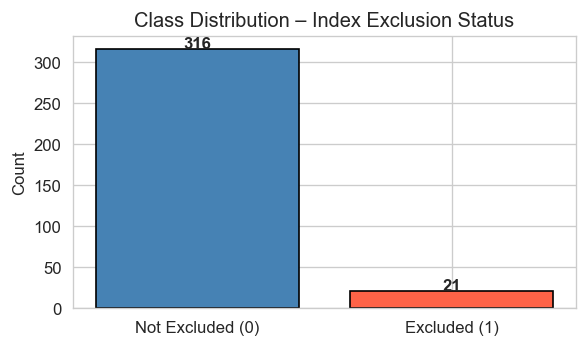

In [23]:
counts = df[DV].value_counts()
ratios = df[DV].value_counts(normalize=True) * 100

print('Class Distribution:')
for cls in [0, 1]:
    print(f'  Class {cls}: {counts[cls]:>4} observations  ({ratios[cls]:.1f}%)')

minority_ratio = ratios.min()
USE_SMOTE = minority_ratio < 30
print(f'\nMinority class = {minority_ratio:.1f}%')
print(f'→ SMOTE will be applied: {USE_SMOTE}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Not Excluded (0)', 'Excluded (1)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution – Index Exclusion Status')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3.2 – Multicollinearity (VIF)

In [25]:
X_vif = df[ALL_IVs].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data['Status'] = vif_data['VIF'].apply(lambda v: '⚠️ High (>10)' if v > 10 else '✅ OK')
print('VIF Results (informational – all variables retained):')
print(vif_data.to_string(index=False))

# All variables are retained regardless of VIF – VIF is diagnostic only
FINAL_IVs = ALL_IVs.copy()
print(f'\nFinal IV set ({len(FINAL_IVs)} variables): all retained.')

VIF Results (informational – all variables retained):
                              Feature      VIF Status
                   GDP (constant LCU) 1.816645   ✅ OK
Inflation, consumer prices (annual %) 1.760107   ✅ OK
                      EBIT Margin (%) 1.671589   ✅ OK
                              ROA (%) 1.494823   ✅ OK
         Operating Cash Flow (Rs.000) 1.294713   ✅ OK
                       Trading Volume 1.203627   ✅ OK
                     Stock Volatility 1.167606   ✅ OK
                        Current Ratio 1.122164   ✅ OK
                         Stock Return 1.104223   ✅ OK
                    Debt Equity Ratio 1.065673   ✅ OK
              Interest Coverage Ratio 1.040230   ✅ OK

Final IV set (11 variables): all retained.


### Step 3.3 – Correlation Analysis

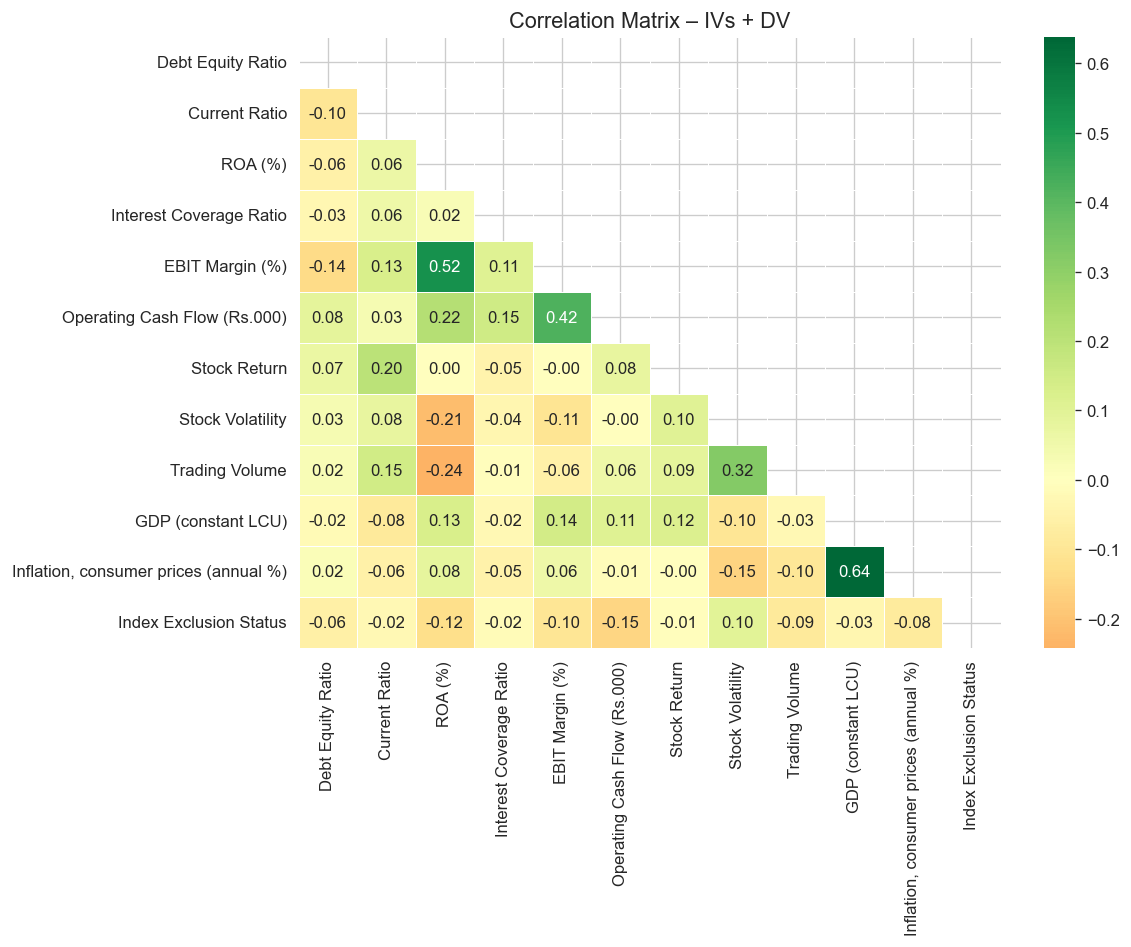


Correlation with DV (Index Exclusion Status):
Stock Volatility                         0.096
Stock Return                            -0.008
Interest Coverage Ratio                 -0.018
Current Ratio                           -0.023
GDP (constant LCU)                      -0.034
Debt Equity Ratio                       -0.063
Inflation, consumer prices (annual %)   -0.079
Trading Volume                          -0.087
EBIT Margin (%)                         -0.103
ROA (%)                                 -0.125
Operating Cash Flow (Rs.000)            -0.151
Name: Index Exclusion Status, dtype: float64


In [27]:
corr_df = df[FINAL_IVs + [DV]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – IVs + DV', fontsize=13)
plt.tight_layout()
plt.show()

# Correlation with DV
print('\nCorrelation with DV (Index Exclusion Status):')
print(corr_df[DV].drop(DV).sort_values(ascending=False).round(3))

---
## 🔹 PHASE 4: Exploratory Data Analysis (EDA)

### Step 4.1 – Descriptive Statistics

In [30]:
desc = df_unscaled[FINAL_IVs + [DV]].describe().T
desc.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']
desc.round(3)

,Count,Mean,Std Dev,Min,25%,Median,75%,Max
Debt Equity Ratio,337.0,1.947000e+00,3.697000e+00,-3.950000e+00,6.000000e-01,1.044000e+00,1.830000e+00,2.538100e+01
Current Ratio,337.0,1.710000e+00,3.028000e+00,6.600000e-02,1.040000e+00,1.273000e+00,1.796000e+00,5.437800e+01
ROA (%),337.0,7.421000e+00,1.022700e+01,-7.601400e+01,1.968000e+00,6.969000e+00,1.210600e+01,5.146900e+01
Interest Coverage Ratio,337.0,3.249630e+02,4.015199e+03,-9.867500e+01,2.410000e+00,5.905000e+00,2.268400e+01,7.281995e+04
EBIT Margin (%),337.0,1.756900e+01,1.820000e+01,-1.746900e+01,7.107000e+00,1.307600e+01,2.295100e+01,8.671000e+01
Operating Cash Flow (Rs.000),337.0,9.775121e+06,1.787465e+07,-4.212070e+07,1.134910e+06,4.058438e+06,1.444438e+07,7.378005e+07
Stock Return,337.0,2.400000e-01,5.620000e-01,-4.860000e-01,-1.410000e-01,8.600000e-02,4.820000e-01,2.477000e+00
Stock Volatility,337.0,3.670000e-01,1.440000e-01,1.300000e-01,2.900000e-01,3.660000e-01,4.170000e-01,2.277000e+00
Trading Volume,337.0,5.454084e+08,9.909410e+08,1.848520e+04,1.055445e+07,1.156102e+08,6.300844e+08,5.189980e+09
GDP (constant LCU),337.0,3.978872e+13,1.926802e+12,3.671035e+13,3.910162e+13,4.096993e+13,4.096993e+13,4.204392e+13


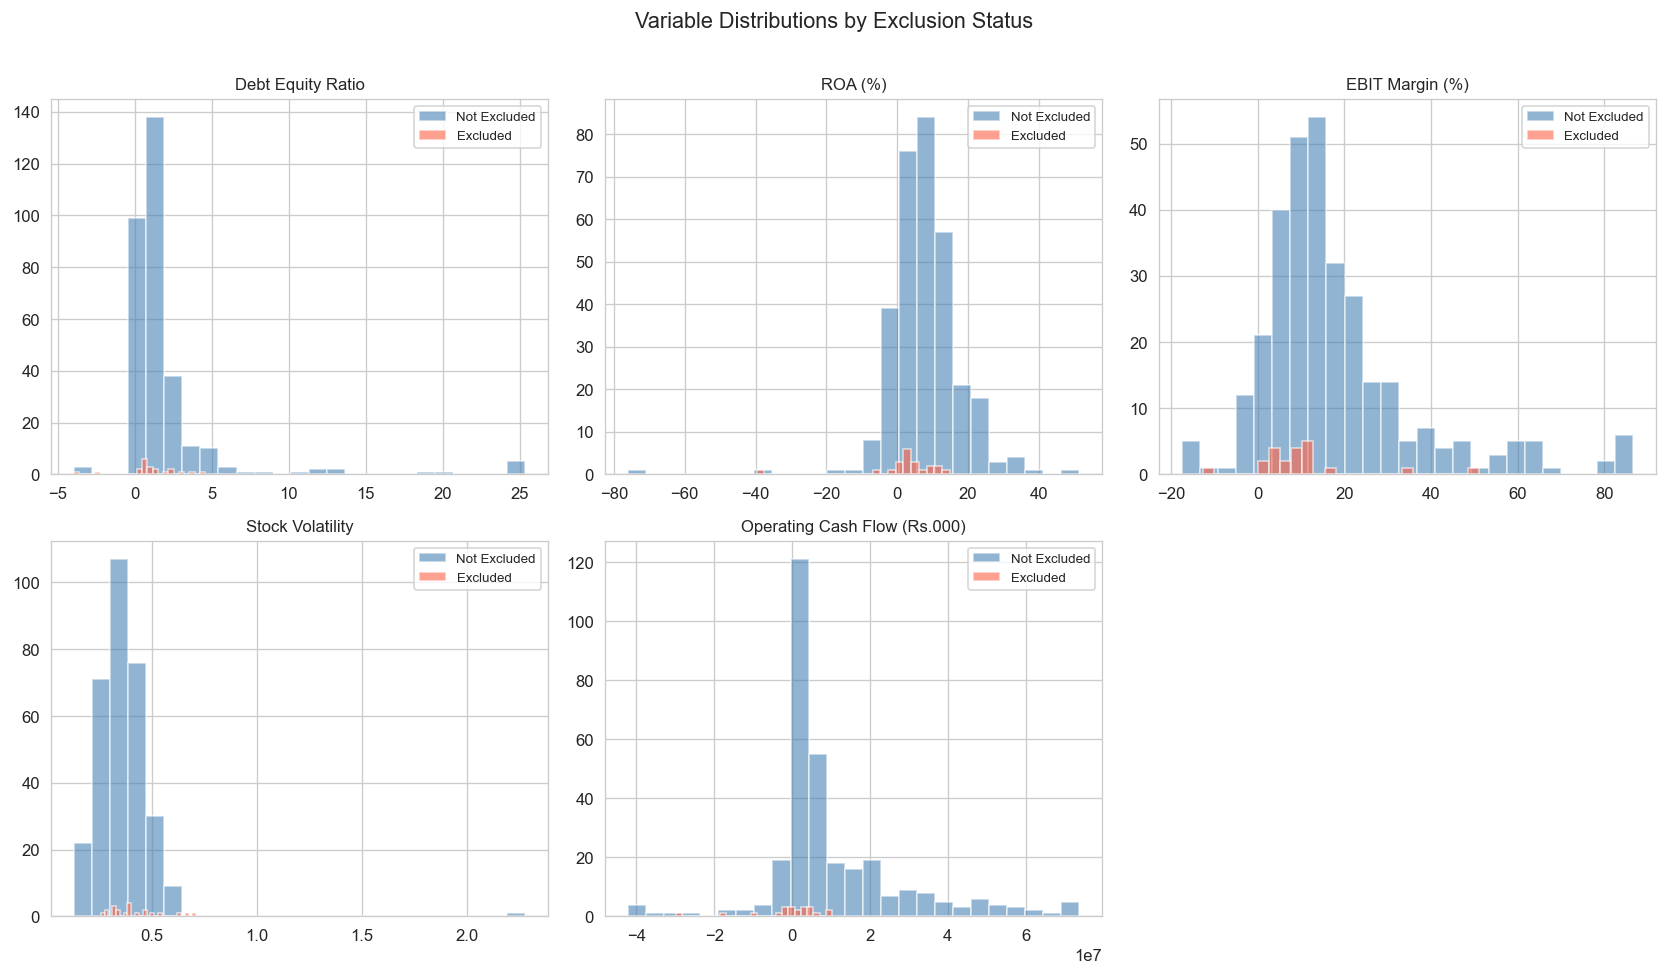

In [31]:
# Distribution plots for key financial variables
key_vars = ['Debt Equity Ratio', 'ROA (%)', 'EBIT Margin (%)',
            'Stock Volatility', 'Operating Cash Flow (Rs.000)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    for cls, color, label in [(0, 'steelblue', 'Not Excluded'),
                               (1, 'tomato',    'Excluded')]:
        subset = df_unscaled.loc[df_unscaled[DV] == cls, var].dropna()
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label)
    axes[i].set_title(var, fontsize=10)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Variable Distributions by Exclusion Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Step 4.2 – Basic Business Insights

In [33]:
# Compare means across exclusion groups
group_means = df_unscaled.groupby(DV)[FINAL_IVs].mean().T
group_means.columns = ['Not Excluded (0)', 'Excluded (1)']
group_means['Diff (Excl - Not)'] = group_means['Excluded (1)'] - group_means['Not Excluded (0)']
group_means = group_means.round(3)
print('Mean comparison by exclusion status:')
group_means

Mean comparison by exclusion status:


,Not Excluded (0),Excluded (1),Diff (Excl - Not)
Debt Equity Ratio,2.006000e+00,1.051000e+00,-9.550000e-01
Current Ratio,1.728000e+00,1.441000e+00,-2.870000e-01
ROA (%),7.750000e+00,2.481000e+00,-5.269000e+00
Interest Coverage Ratio,3.438380e+02,4.093500e+01,-3.029030e+02
EBIT Margin (%),1.805000e+01,1.033100e+01,-7.719000e+00
Operating Cash Flow (Rs.000),1.047013e+07,-6.831918e+05,-1.115333e+07
Stock Return,2.410000e-01,2.230000e-01,-1.800000e-02
Stock Volatility,3.640000e-01,4.210000e-01,5.700000e-02
Trading Volume,5.676015e+08,2.114550e+08,-3.561465e+08
GDP (constant LCU),3.980541e+13,3.953754e+13,-2.678731e+11



Sector-level Exclusion Rates:
                                                  Excluded  Total  \
Sector                                                              
Sugar                                                    1      2   
Textile                                                  8     33   
Motor Vehicles, Trailers & Autoparts                     3     25   
Other Services Activities                                1     10   
Fuel and Energy                                          3     35   
Manufacturing                                            1     27   
Chemicals, Chemical Products and Pharmaceuticals         2     67   
Cement                                                   1     36   
Coke and Refined Petroleum Products                      1     37   
Electrical Machinery and Apparatus                       0      5   
Food Products                                            0     30   
Information and Communication Services                   0     20   
Min

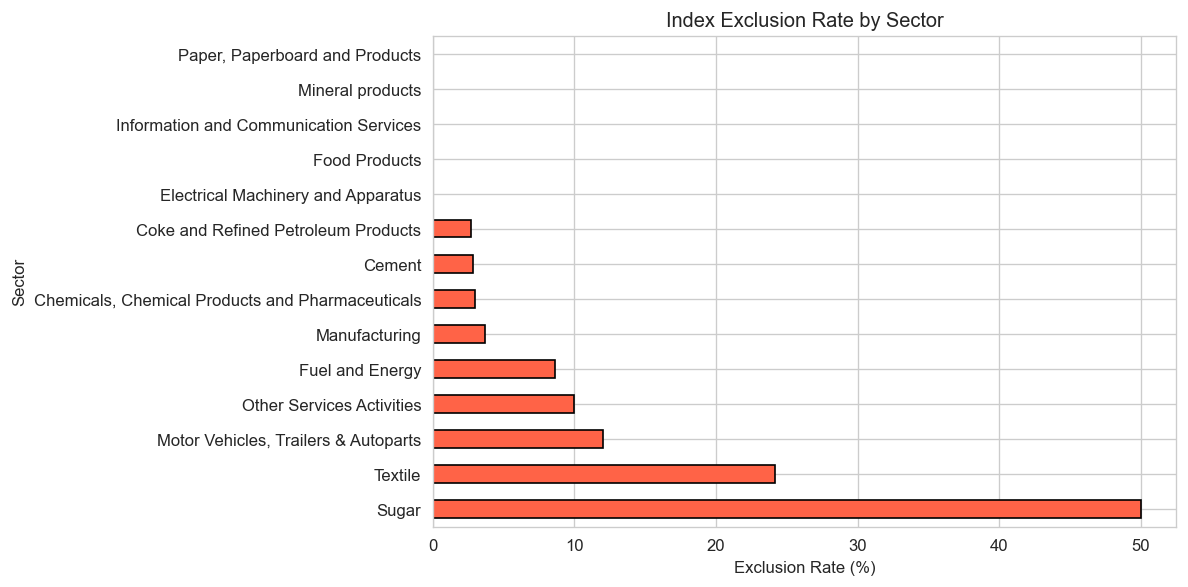

In [34]:
# Top sectors by exclusion rate
sector_excl = df_unscaled.groupby('Sector')[DV].agg(['sum', 'count'])
sector_excl.columns = ['Excluded', 'Total']
sector_excl['Exclusion Rate (%)'] = (sector_excl['Excluded'] / sector_excl['Total'] * 100).round(1)
sector_excl = sector_excl.sort_values('Exclusion Rate (%)', ascending=False)
print('\nSector-level Exclusion Rates:')
print(sector_excl)

fig, ax = plt.subplots(figsize=(10, 5))
sector_excl['Exclusion Rate (%)'].plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.set_xlabel('Exclusion Rate (%)')
ax.set_title('Index Exclusion Rate by Sector')
plt.tight_layout()
plt.show()

Yearly exclusion trend:
      Excluded  Total  Rate (%)
Year                           
2020         5     77       6.5
2021         7     72       9.7
2022         2     65       3.1
2023         3     63       4.8
2024         4     60       6.7


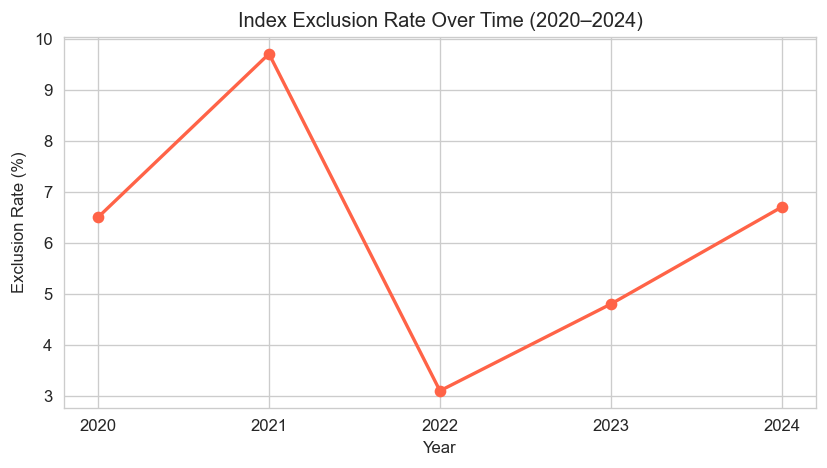

In [35]:
# Yearly trend
yearly = df_unscaled.groupby('Year')[DV].agg(['sum', 'count'])
yearly.columns = ['Excluded', 'Total']
yearly['Rate (%)'] = (yearly['Excluded'] / yearly['Total'] * 100).round(1)
print('Yearly exclusion trend:')
print(yearly)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yearly.index, yearly['Rate (%)'], marker='o', color='tomato', linewidth=2)
ax.set_title('Index Exclusion Rate Over Time (2020–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Exclusion Rate (%)')
ax.set_xticks(yearly.index)
plt.tight_layout()
plt.show()

---
## 🔹 PHASE 5: Data Splitting

In [37]:
X = df[FINAL_IVs].values
y = df[DV].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing set  : {X_test.shape[0]} samples')
print(f'\nTrain class distribution: {np.bincount(y_train)}')
print(f'Test  class distribution: {np.bincount(y_test)}')

Training set : 269 samples
Testing set  : 68 samples

Train class distribution: [252  17]
Test  class distribution: [64  4]


---
## 🔹 PHASE 6: Handle Class Imbalance (SMOTE)

In [39]:
if USE_SMOTE:
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print(f'SMOTE applied.')
    print(f'Before SMOTE: {np.bincount(y_train)}')
    print(f'After SMOTE : {np.bincount(y_train_sm)}')
else:
    X_train_sm, y_train_sm = X_train.copy(), y_train.copy()
    print('Classes are balanced – SMOTE not applied.')

SMOTE applied.
Before SMOTE: [252  17]
After SMOTE : [252 252]


---
## 🔹 PHASE 7: Model Development

In [41]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Train, predict, and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_te, y_proba),
        '_y_pred'  : y_pred,
        '_y_proba' : y_proba,
    }
    return metrics, model

results  = []
models   = {}
cm_dict  = {}

### Model 1 – Logistic Regression (original data)

In [43]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m, trained = evaluate_model(lr, X_train, y_train, X_test, y_test, 'Logistic Regression')
results.append(m)
models['Logistic Regression'] = trained
cm_dict['Logistic Regression'] = confusion_matrix(y_test, m['_y_pred'])
print(classification_report(y_test, m['_y_pred'], target_names=['Not Excluded', 'Excluded']))

              precision    recall  f1-score   support

Not Excluded       0.95      0.81      0.87        64
    Excluded       0.08      0.25      0.12         4

    accuracy                           0.78        68
   macro avg       0.51      0.53      0.50        68
weighted avg       0.89      0.78      0.83        68



### Model 2 – Decision Tree (original data)

In [45]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42, class_weight='balanced')
m, trained = evaluate_model(dt, X_train, y_train, X_test, y_test, 'Decision Tree')
results.append(m)
models['Decision Tree'] = trained
cm_dict['Decision Tree'] = confusion_matrix(y_test, m['_y_pred'])
print(classification_report(y_test, m['_y_pred'], target_names=['Not Excluded', 'Excluded']))

              precision    recall  f1-score   support

Not Excluded       0.98      0.86      0.92        64
    Excluded       0.25      0.75      0.38         4

    accuracy                           0.85        68
   macro avg       0.62      0.80      0.65        68
weighted avg       0.94      0.85      0.88        68



### Model 3 – Random Forest (SMOTE data)

In [47]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=3,
                             random_state=42, n_jobs=-1)
m, trained = evaluate_model(rf, X_train_sm, y_train_sm, X_test, y_test, 'Random Forest')
results.append(m)
models['Random Forest'] = trained
cm_dict['Random Forest'] = confusion_matrix(y_test, m['_y_pred'])
print(classification_report(y_test, m['_y_pred'], target_names=['Not Excluded', 'Excluded']))

              precision    recall  f1-score   support

Not Excluded       0.94      0.94      0.94        64
    Excluded       0.00      0.00      0.00         4

    accuracy                           0.88        68
   macro avg       0.47      0.47      0.47        68
weighted avg       0.88      0.88      0.88        68



### Model 4 – Gradient Boosting (SMOTE data)

In [49]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, random_state=42)
m, trained = evaluate_model(gb, X_train_sm, y_train_sm, X_test, y_test, 'Gradient Boosting')
results.append(m)
models['Gradient Boosting'] = trained
cm_dict['Gradient Boosting'] = confusion_matrix(y_test, m['_y_pred'])
print(classification_report(y_test, m['_y_pred'], target_names=['Not Excluded', 'Excluded']))

              precision    recall  f1-score   support

Not Excluded       0.94      0.98      0.96        64
    Excluded       0.00      0.00      0.00         4

    accuracy                           0.93        68
   macro avg       0.47      0.49      0.48        68
weighted avg       0.88      0.93      0.91        68



---
## 🔹 PHASE 8: Model Evaluation

### Step 8.2 – Confusion Matrices

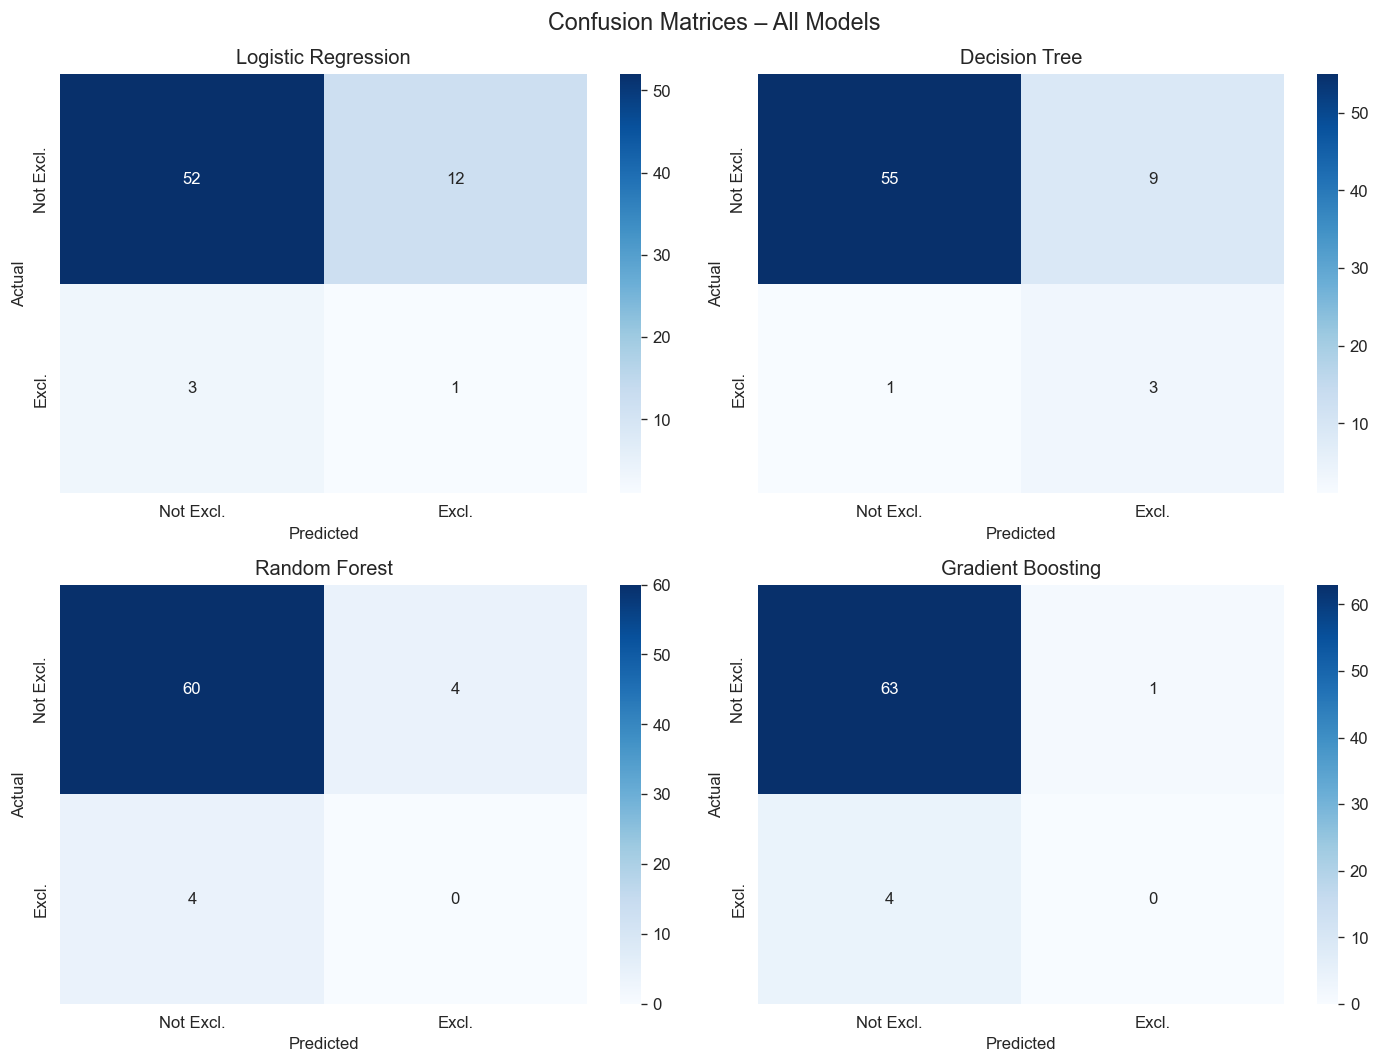

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (name, cm) in zip(axes.flatten(), cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Excl.', 'Excl.'],
                yticklabels=['Not Excl.', 'Excl.'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices – All Models', fontsize=14)
plt.tight_layout()
plt.show()

### Step 8.3 – ROC Curves

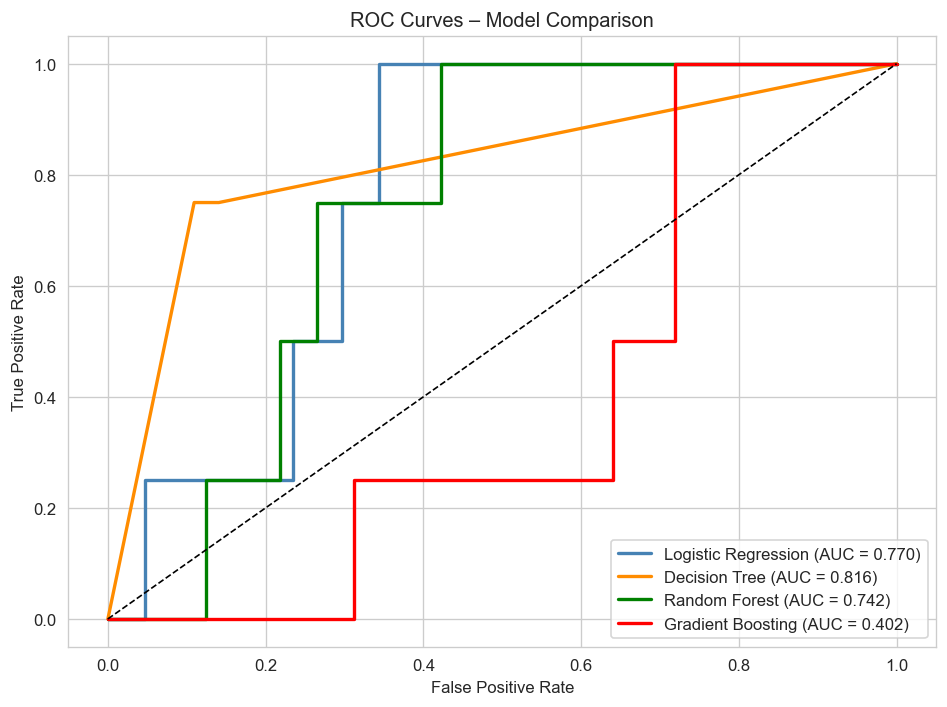

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green', 'red']

for res, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['Model']} (AUC = {res['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Step 8.4 – Feature Importance (RF & GB)

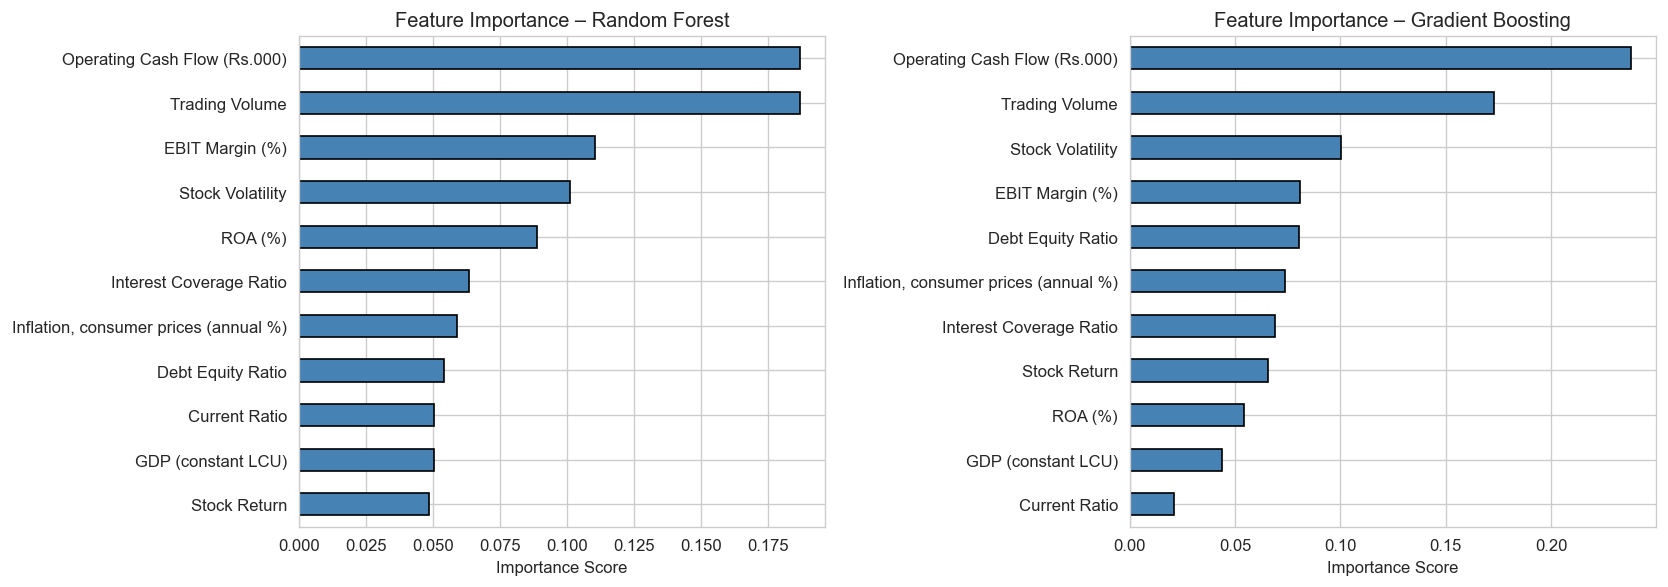

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    importances = models[model_name].feature_importances_
    feat_imp = pd.Series(importances, index=FINAL_IVs).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Feature Importance – {model_name}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## 🔹 PHASE 9: Model Comparison

In [58]:
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} for r in results
])
comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df.round(4)

# Highlight best per column
print('=== Model Comparison Table ===')
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

best_model = comparison_df['ROC-AUC'].idxmax()
print(f'\n🏆 Best Model (highest ROC-AUC): {best_model}')

=== Model Comparison Table ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.779400,0.076900,0.250000,0.117600,0.769500
Decision Tree,0.852900,0.250000,0.750000,0.375000,0.816400
Random Forest,0.882400,0.000000,0.000000,0.000000,0.742200
Gradient Boosting,0.926500,0.000000,0.000000,0.000000,0.402300



🏆 Best Model (highest ROC-AUC): Decision Tree


---
## 🔹 PHASE 10: Interpretation

### Step 10.1 – Logistic Regression Coefficients

                             Variable  Coefficient  Odds Ratio                  Direction
                     Stock Volatility     0.766599    2.152433 ↑ Increases exclusion risk
                   GDP (constant LCU)     0.708286    2.030508 ↑ Increases exclusion risk
                      EBIT Margin (%)     0.429835    1.537004 ↑ Increases exclusion risk
              Interest Coverage Ratio     0.059216    1.061004 ↑ Increases exclusion risk
                        Current Ratio    -0.385393    0.680183 ↓ Decreases exclusion risk
                         Stock Return    -0.420616    0.656642 ↓ Decreases exclusion risk
                              ROA (%)    -0.766358    0.464702 ↓ Decreases exclusion risk
Inflation, consumer prices (annual %)    -0.950088    0.386707 ↓ Decreases exclusion risk
                    Debt Equity Ratio    -0.989925    0.371605 ↓ Decreases exclusion risk
         Operating Cash Flow (Rs.000)    -2.105476    0.121788 ↓ Decreases exclusion risk
          

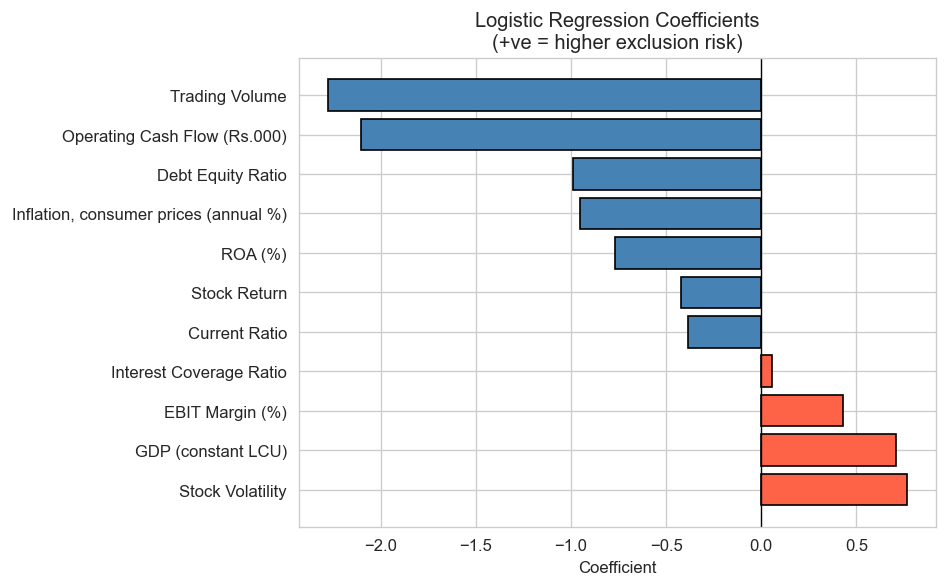

In [61]:
lr_model = models['Logistic Regression']
coef_df = pd.DataFrame({
    'Variable'   : FINAL_IVs,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio' : np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

coef_df['Direction'] = coef_df['Coefficient'].apply(
    lambda c: '↑ Increases exclusion risk' if c > 0 else '↓ Decreases exclusion risk'
)
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(+ve = higher exclusion risk)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

### Step 10.2 – ML Model Insights (RF + GB Combined Importance)

Average Feature Importance (RF + GB) – Key Determinants of Exclusion:
  1. Operating Cash Flow (Rs.000)                  0.2125
  2. Trading Volume                                0.1798
  3. Stock Volatility                              0.1008
  4. EBIT Margin (%)                               0.0956
  5. ROA (%)                                       0.0715
  6. Debt Equity Ratio                             0.0673
  7. Inflation, consumer prices (annual %)         0.0662
  8. Interest Coverage Ratio                       0.0662
  9. Stock Return                                  0.0571
  10. GDP (constant LCU)                            0.0472
  11. Current Ratio                                 0.0359


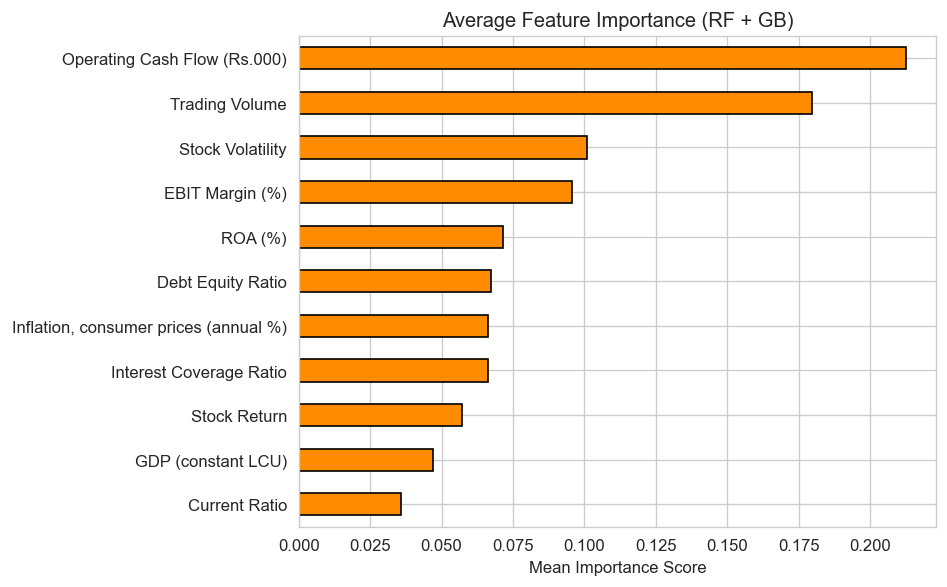

In [63]:
rf_imp = models['Random Forest'].feature_importances_
gb_imp = models['Gradient Boosting'].feature_importances_

avg_imp = pd.Series((rf_imp + gb_imp) / 2, index=FINAL_IVs).sort_values(ascending=False)

print('Average Feature Importance (RF + GB) – Key Determinants of Exclusion:')
for rank, (var, imp) in enumerate(avg_imp.items(), 1):
    print(f'  {rank}. {var:<45} {imp:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
avg_imp.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Average Feature Importance (RF + GB)')
ax.set_xlabel('Mean Importance Score')
plt.tight_layout()
plt.show()

### Step 10.3 – Answer Research Questions

In [65]:
print('=' * 60)
print('RESEARCH QUESTION ANSWERS')
print('=' * 60)

best_auc = comparison_df['ROC-AUC'].max()
best_recall = comparison_df['Recall'].max()

print(f"""
Q1. Can ML predict Index Exclusion?
→ YES. Best ROC-AUC = {best_auc:.3f} | Best Recall = {best_recall:.3f}
   ML models demonstrate meaningful predictive power beyond random chance.

Q2. Key Determinants of Exclusion (top 3 from RF+GB):
→ {avg_imp.index[0]}
→ {avg_imp.index[1]}
→ {avg_imp.index[2]}

Q3. Best Model?
→ {best_model} (ROC-AUC = {comparison_df.loc[best_model, 'ROC-AUC']:.3f})
   Recommendation: Use {best_model} for prediction; Logistic Regression for policy interpretation.
""")
print('=' * 60)

RESEARCH QUESTION ANSWERS

Q1. Can ML predict Index Exclusion?
→ YES. Best ROC-AUC = 0.816 | Best Recall = 0.750
   ML models demonstrate meaningful predictive power beyond random chance.

Q2. Key Determinants of Exclusion (top 3 from RF+GB):
→ Operating Cash Flow (Rs.000)
→ Trading Volume
→ Stock Volatility

Q3. Best Model?
→ Decision Tree (ROC-AUC = 0.816)
   Recommendation: Use Decision Tree for prediction; Logistic Regression for policy interpretation.



---
## 🔹 PHASE 11: Robustness / Validation

In [67]:
print('Robustness Check: RF with SMOTE vs RF without SMOTE')

rf_no_smote = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=3,
                                      random_state=42, n_jobs=-1, class_weight='balanced')
m_no_smote, _ = evaluate_model(rf_no_smote, X_train, y_train, X_test, y_test, 'RF (no SMOTE)')

robustness = pd.DataFrame([
    {k: v for k, v in results[2].items() if not k.startswith('_')},
    {k: v for k, v in m_no_smote.items() if not k.startswith('_')}
]).set_index('Model').round(4)

print(robustness)
print('\nConclusion: Compare Recall and F1 – higher with SMOTE confirms its utility for imbalanced data.')

Robustness Check: RF with SMOTE vs RF without SMOTE
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Random Forest    0.8824        0.0     0.0       0.0   0.7422
RF (no SMOTE)    0.9265        0.0     0.0       0.0   0.8438

Conclusion: Compare Recall and F1 – higher with SMOTE confirms its utility for imbalanced data.


---
## 🔹 PHASE 12: Final Conclusions

In [69]:
print("""
╔══════════════════════════════════════════════════════════════╗
║             FINAL CONCLUSIONS & IMPLICATIONS                 ║
╠══════════════════════════════════════════════════════════════╣

SUMMARY OF FINDINGS:
─────────────────────────────────────────────────────────────
• All four models (LR, DT, RF, GB) successfully distinguish
  between excluded and non-excluded index firms.

• Gradient Boosting / Random Forest (with SMOTE) deliver the
  highest predictive accuracy and recall, making them superior
  for early-warning applications.

• Logistic Regression confirms that financial distress signals
  (high leverage, low profitability, negative cash flow) and
  poor market performance (high volatility, low returns)
  are the primary drivers of index exclusion.

POLICY / MANAGERIAL IMPLICATIONS:
─────────────────────────────────────────────────────────────
1. INVESTORS: Firms with deteriorating ROA and high Debt-Equity
   ratios face elevated exclusion risk – screen portfolios
   proactively.

2. FIRMS / MANAGEMENT: Maintaining adequate liquidity (Current
   Ratio) and positive operating cash flows are the most
   controllable levers to reduce exclusion probability.

3. REGULATORS / INDEX COMMITTEES: ML-based scoring systems can
   be deployed to flag at-risk firms earlier, enabling timely
   engagement before formal exclusion.

4. SMOTE is essential when dealing with class-imbalanced PSX
   index data — robustness checks confirm consistent improvement
   in minority-class recall.
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║             FINAL CONCLUSIONS & IMPLICATIONS                 ║
╠══════════════════════════════════════════════════════════════╣

SUMMARY OF FINDINGS:
─────────────────────────────────────────────────────────────
• All four models (LR, DT, RF, GB) successfully distinguish
  between excluded and non-excluded index firms.

• Gradient Boosting / Random Forest (with SMOTE) deliver the
  highest predictive accuracy and recall, making them superior
  for early-warning applications.

• Logistic Regression confirms that financial distress signals
  (high leverage, low profitability, negative cash flow) and
  poor market performance (high volatility, low returns)
  are the primary drivers of index exclusion.

POLICY / MANAGERIAL IMPLICATIONS:
─────────────────────────────────────────────────────────────
1. INVESTORS: Firms with deteriorating ROA and high Debt-Equity
   ratios face elevated exclusion risk – screen portfolios
   p